In [1]:
from PINN_XWave_DDP import *

In [2]:
#Global variables physics constants
vth = .1
omega_ce = 2.
omega = 2.5
omega_pe = 1.0
phi_amp = 1.
B0 = 1.0  # Background magnetic field strength


k, k_lambda_D = dispersion(omega, omega_ce, omega_pe, vth)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

omega_list = [omega]
phi_amp_list = [phi_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution
B0_list = [B0]

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin         # Length of the domain
tau = tmax - tmin       # Time duration of the wave
Nt = 2000               # Number of time points
Nx = 2000               # Number of spatial points
Nt_coll = 200           #number of collocation points in time
Nx_coll = 200           #number of collocation points in space
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambda_debye = {k_lambda_D:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_arr, T_arr, phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat = generate_data(xmin = xmin, xmax = xmax, tmin = tmin, tmax = tmax, nx = Nx, nt = Nt, vth=vth,
                                                                                                omega_ce = omega_ce, omega_pe = omega_pe, omega_list = omega_list, phi_amp_list=phi_amp_list,
                                                                                                delta_list=delta_list)

x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_arr, T_arr, phi_flat, Bdot_flat, num_samples=500)

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)
print(f"Number of collocation points: {len(x_coll)}")
print(f"Number of grid points: {len(X_arr)}")

k = 1.432, k*lambda_D = 0.143
k = 1.4318e+00
k lambda_debye = 1.4318e-01
L = 1.317e+01 [c / omega_pe]
T = 2.513e+00 [1 / omega_pe]
dx = 6.583e-03 [c / omega_pe]
dt = 1.257e-03 [1 / omega_pe]
Number of collocation points: 40000
Number of grid points: 4000000


In [3]:
def compare_spacing(k, omega, dx, dt):
    k_lambda_D = k * np.sqrt(1 + (omega / omega_ce)**2)
    print(f"k*lambda_D = {k_lambda_D:.4e}")
    
    # Calculate the number of wavelengths in the domain
    num_wavelengths = (xmax - xmin) / (2 * np.pi / k)
    print(f"Number of wavelengths in the domain: {num_wavelengths:.2f}")
    
    # Calculate the number of time periods in the domain
    num_periods = (tmax - tmin) / (2 * np.pi / omega)
    print(f"Number of time periods in the domain: {num_periods:.2f}")
    
    return 
compare_spacing(k, omega, dx, dt)

k*lambda_D = 2.2920e+00
Number of wavelengths in the domain: 3.00
Number of time periods in the domain: 3.00


-------Plotting Ground Truth Values-------------


<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_956446/3542494858.py:5: SyntaxWarning: invalid escape sequence '\p'
  titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$',
/tmp/ipykernel_956446/3542494858.py:6: SyntaxWarning: invalid escape sequence '\d'
  f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',


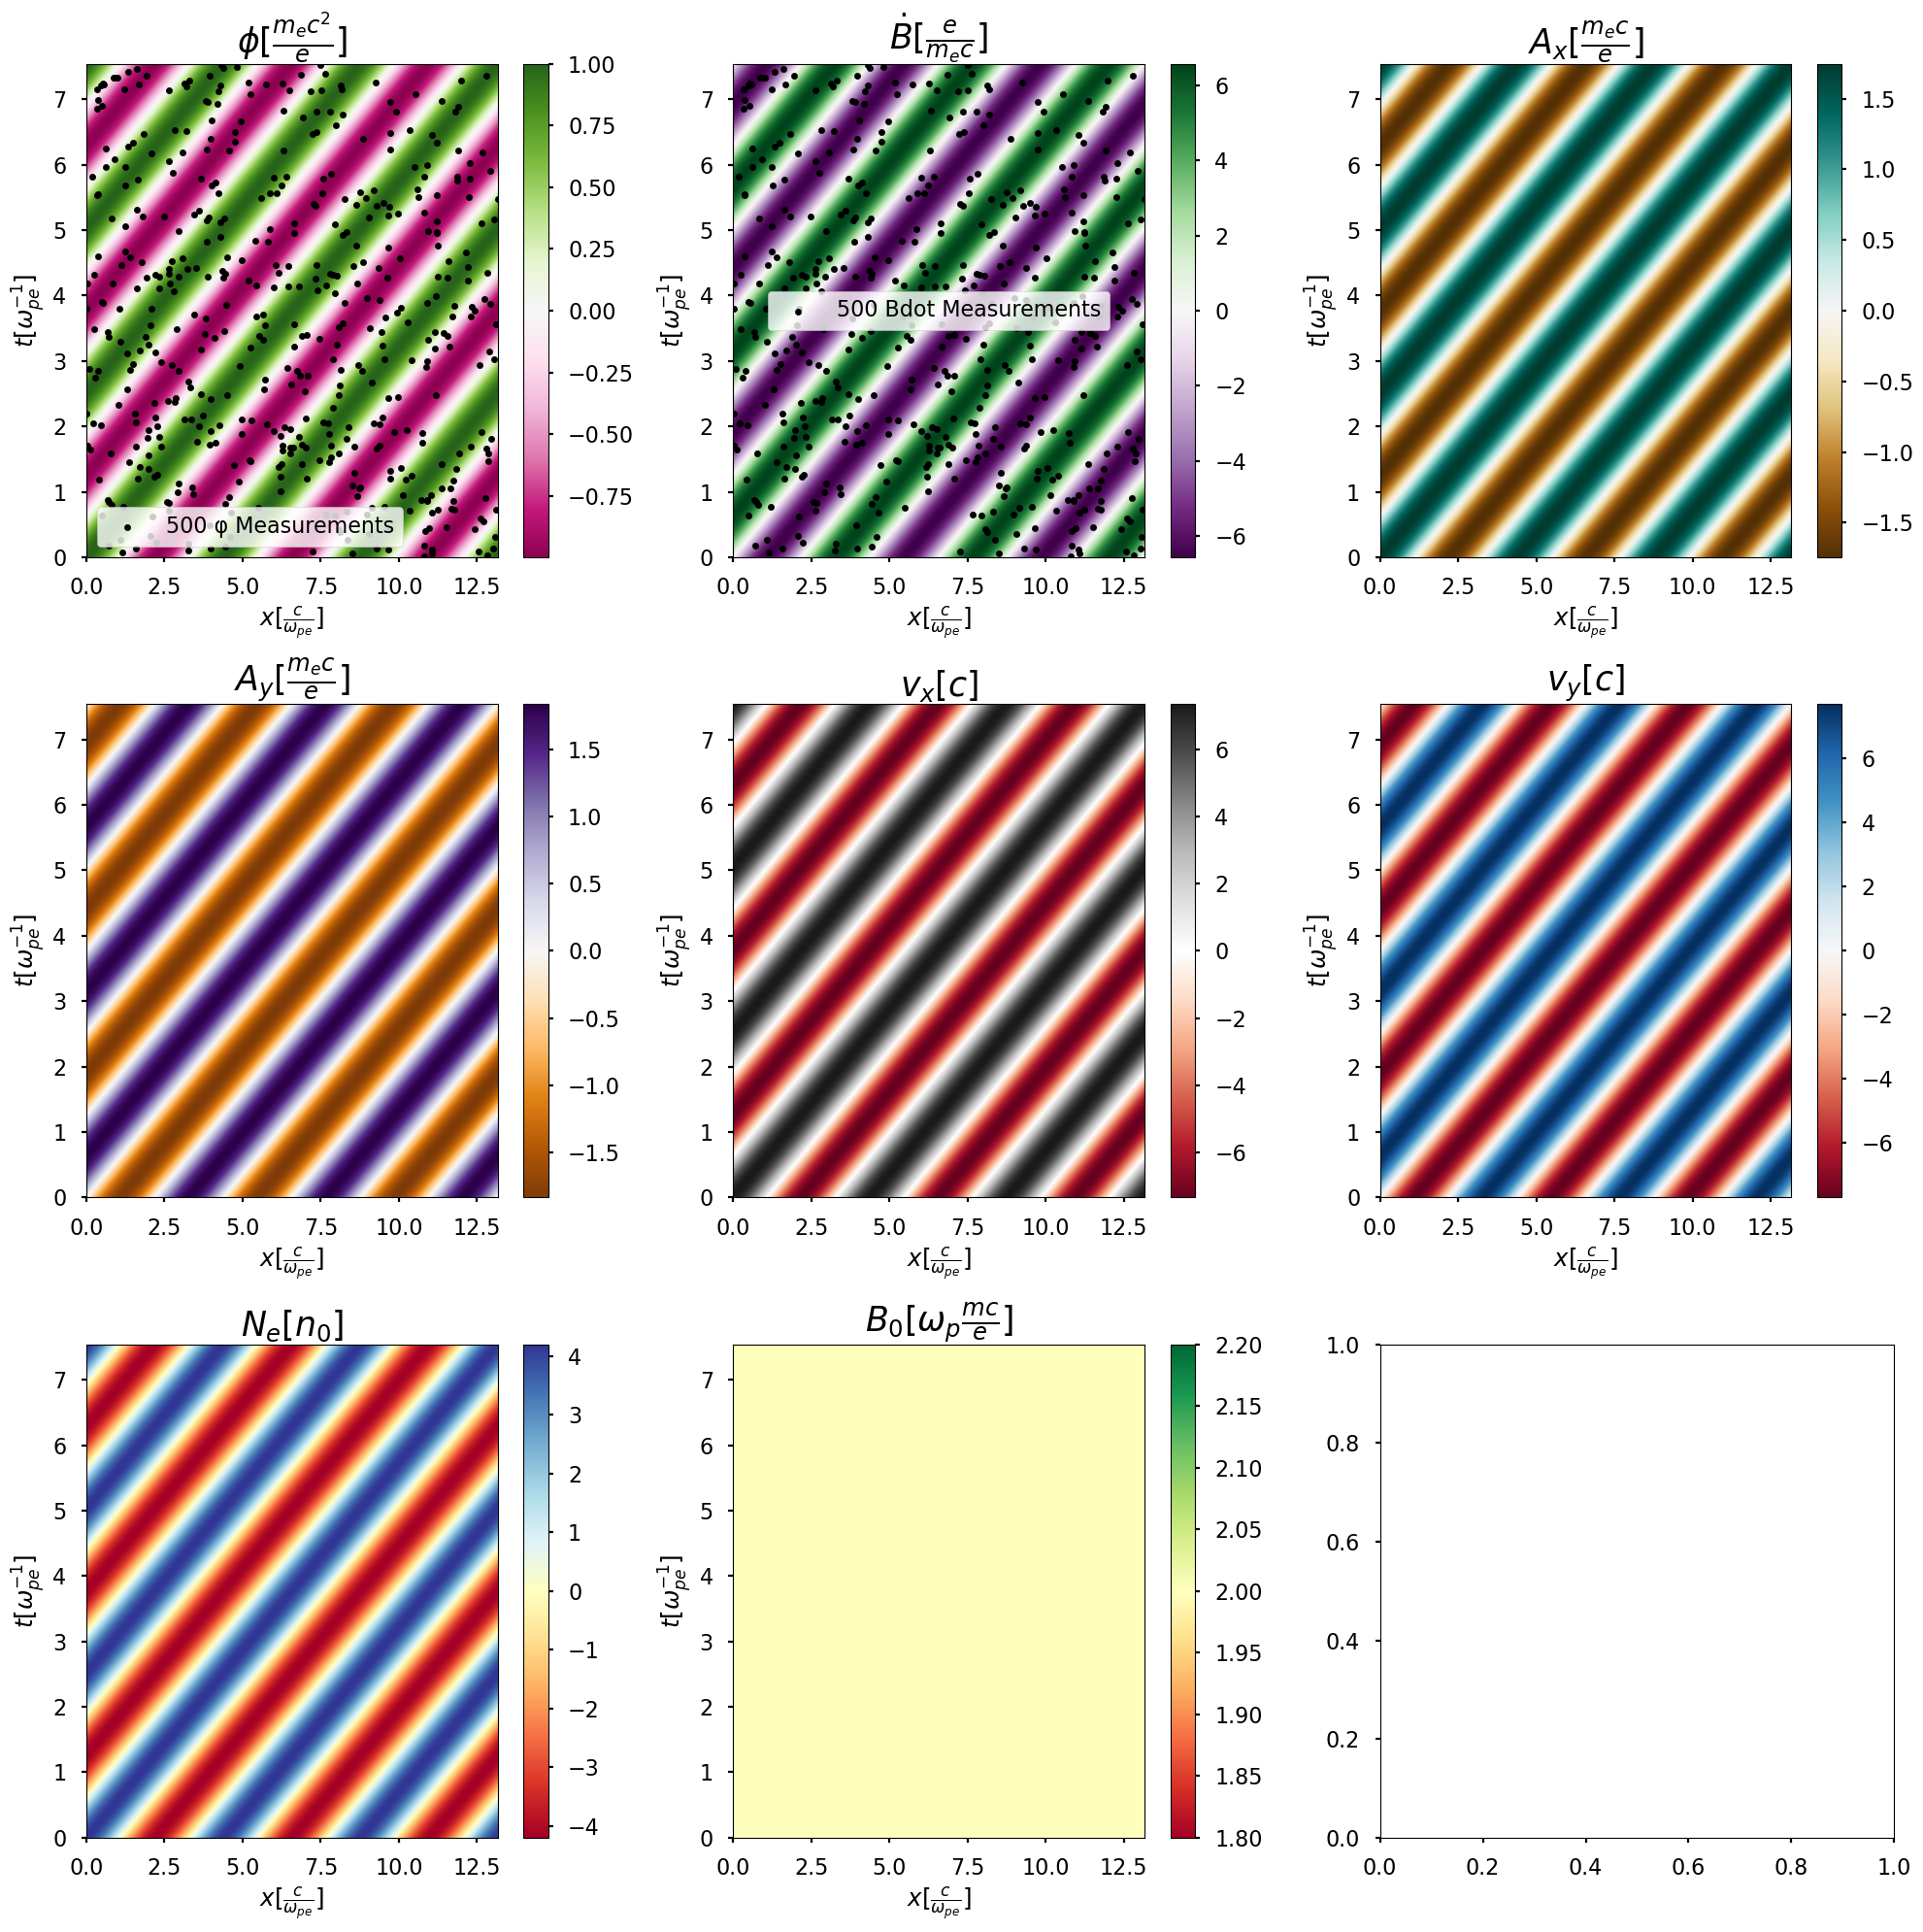

<Figure size 1280x880 with 0 Axes>

In [4]:
quantities_flat = np.real(np.array([phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat])) #Take real part 
extent_GT = [xmin, xmax, tmin, tmax]                                    #Extent of the ground truth values
quantities_GT = [x.reshape(Nt, Nx) for x in quantities_flat]            #Reshape to 2D arrays in the shape of the collocation points
sparse = [x_sparse, t_sparse, phi_sparse, Bdot_sparse]                  #sparse phi and Bdot measurements
titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$', 
            f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',
            f'$A_x [\\frac{{m_{{e}}c}}{{e}}]$',
            f'$A_y [\\frac{{m_{{e}}c}}{{e}}]$',
            f'$v_x [c]$', 
            f'$v_y [c]$', 
            f'$N_e [n_0]$',
            r'$B_0 [\omega_p \frac{mc}{e}]$']

#Plot Ground Truth Values
print("-------Plotting Ground Truth Values-------------")
plot_analytical(quantities=quantities_GT, sparse = sparse, titles = titles_GT, extent = extent_GT)

In [5]:
#Plot constraints
phi = np.real(np.array(quantities_GT[0]))
Bdot = np.real(np.array(quantities_GT[1]))
Ax = np.real(np.array(quantities_GT[2]))
Ay = np.real(np.array(quantities_GT[3]))
Vx = np.real(np.array(quantities_GT[4]))
Vy = np.real(np.array(quantities_GT[5]))
N = np.real(np.array(quantities_GT[6]))
B0 = np.real(np.array(quantities_GT[7]))

def spectral_derivatives_2d(f, t, x, deriv_type='x', filter_factor = .5):
    """
    Computes a partial derivative of a 2D function f(t, x) using the spectral method.

    Args:
        f (np.ndarray): A 2D numpy array representing the function f(t, x).
                        The first dimension is time, the second is space.
        t (np.ndarray): 1D array of time points.
        x (np.ndarray): 1D array of spatial points.
        deriv_type (str): The type of derivative to compute ('t', 'x', 'tt', 'xx', 'xt').

    Returns:
        np.ndarray: A 2D array containing the computed partial derivative.
    """
    Nt, Nx = f.shape
    dt = t[1] - t[0]
    dx = x[1] - x[0]

    # Perform 2D FFT to move to the frequency domain
    f_hat = np.fft.fft2(f)

    # Generate wave number arrays for time (omega) and space (k)
    omega = 2 * np.pi * np.fft.fftfreq(Nt, d=dt)
    k = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    omega_grid, k_grid = np.meshgrid(omega, k, indexing='ij')

    # Add filtering to remove high-frequency noise
    f_hat_filtered = np.zeros_like(f_hat)
    num_to_keep_t = int(Nt * filter_factor)
    num_to_keep_x = int(Nx * filter_factor)

    # Filter by keeping only the central low-frequency modes
    f_hat_filtered[0:num_to_keep_t//2, 0:num_to_keep_x//2] = f_hat[0:num_to_keep_t//2, 0:num_to_keep_x//2]
    f_hat_filtered[-num_to_keep_t//2:, 0:num_to_keep_x//2] = f_hat[-num_to_keep_t//2:, 0:num_to_keep_x//2]
    f_hat_filtered[0:num_to_keep_t//2, -num_to_keep_x//2:] = f_hat[0:num_to_keep_t//2, -num_to_keep_x//2:]
    f_hat_filtered[-num_to_keep_t//2:, -num_to_keep_x//2:] = f_hat[-num_to_keep_t//2:, -num_to_keep_x//2:]


    # Apply the appropriate differentiation rule in the frequency domain
    if deriv_type == 'x':
        deriv_hat = 1j * k_grid * f_hat
    elif deriv_type == 't':
        deriv_hat = 1j * omega_grid * f_hat
    elif deriv_type == 'xx':
        deriv_hat = -(k_grid**2) * f_hat
    elif deriv_type == 'tt':
        deriv_hat = -(omega_grid**2) * f_hat
    elif deriv_type == 'xt':
        deriv_hat = -(omega_grid * k_grid) * f_hat
    else:
        raise ValueError("Invalid derivative type. Choose from 'x', 't', 'xx', 'tt', 'xt'.")

    # Perform 2D inverse FFT to return to the spatial domain
    deriv = np.fft.ifft2(deriv_hat)

    return deriv.real

#spatial derivatives use 1 and temporal use 0
# phi_x = np.gradient(phi, dx, axis=1, edge_order = 2) 
# phi_xx = np.gradient(phi_x, dx, axis=1, edge_order = 2) 
# phi_t = np.gradient(phi, dt, axis=0, edge_order = 2) 
# phi_tt = np.gradient(phi_t, dt, axis=0, edge_order = 2) 
# phi_xt = np.gradient(phi_x, dt, axis=0, edge_order = 2)

# Ax_x = np.gradient(Ax, dx, axis=1, edge_order = 2)
# Ax_xx = np.gradient(Ax_x, dx, axis=1, edge_order = 2) 
# Ax_t = np.gradient(Ax, dt, axis=0, edge_order = 2)
# Ax_tt = np.gradient(Ax_t, dt, axis=0, edge_order = 2)
# Ax_xt = np.gradient(Ax_x, dt, axis=0, edge_order = 2) 
# Ay_x = np.gradient(Ay, dx, axis=1, edge_order = 2) 
# Ay_xx = np.gradient(Ay_x, dx, axis=1, edge_order = 2) 
# Ay_t = np.gradient(Ay, dt, axis=0, edge_order = 2)
# Ay_tt = np.gradient(Ay_t, dt, axis=0, edge_order = 2) 
# Ay_xt = np.gradient(Ay_x, dt, axis=0, edge_order = 2)

# Vx_x = np.gradient(Vx, dx, axis=1, edge_order = 2) 
# Vx_t = np.gradient(Vx, dt, axis=0, edge_order = 2)
# Vy_x = np.gradient(Vy, dx, axis=1, edge_order = 2)
# Vy_t = np.gradient(Vy, dt, axis=0, edge_order = 2) 

# N_t = np.gradient(N, dt, axis=0, edge_order = 2)

#Finite Difference derivatives
phi_x = derivative_x(phi, dx)
phi_xx = derivative_xx(phi, dx)
phi_t = derivative_t(phi, dt)
phi_tt = derivative_tt(phi, dt)
phi_xt = derivative_xt(phi, dx=dx, dt=dt)

Ax_x = derivative_x(Ax, dx)
Ax_xx = derivative_xx(Ax, dx)
Ax_t = derivative_t(Ax, dt)
Ax_tt = derivative_tt(Ax, dt)
Ax_xt = derivative_xt(Ax, dx=dx, dt=dt)
Ay_x = derivative_x(Ay, dx)
Ay_xx = derivative_xx(Ay, dx)
Ay_t = derivative_t(Ay, dt)
Ay_tt = derivative_tt(Ay_t, dt)
Ay_xt = derivative_xt(Ay, dx=dx, dt=dt)

Vx_x = derivative_x(Vx, dx)
Vx_t = derivative_t(Vx, dt)
Vy_x = derivative_x(Vy, dx)
Vy_t = derivative_t(Vy, dt)

N_t = derivative_t(N, dt)

#Spectral derivatives
# phi_x = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='x')
# phi_xx = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xx')
# phi_t = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='t')
# phi_tt = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='tt')
# phi_xt = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xt')

# Ax_x = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='x')
# Ax_xx = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='xx')
# Ax_t = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='t')
# Ax_tt = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='tt')
# Ax_xt = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='xt')
# Ay_x = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='x')
# Ay_xx = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='xx')
# Ay_t = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='t')
# Ay_tt = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='tt')
# Ay_xt = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='xt')

# Vx_x = spectral_derivatives_2d(Vx, x_arr, t_arr, deriv_type='x')
# Vx_t = spectral_derivatives_2d(Vx, x_arr, t_arr, deriv_type='t')
# Vy_x = spectral_derivatives_2d(Vy, x_arr, t_arr, deriv_type='x')
# Vy_t = spectral_derivatives_2d(Vy, x_arr, t_arr, deriv_type='t')

# N_t = spectral_derivatives_2d(N, x_arr, t_arr, deriv_type='t')


#Constraints
# gauge = Ax_x + phi_t                                #Gauge
# maxwell_den = phi_xx + Ax_xt - N                    #Maxwell_den
# maxwell_cur_x = -Ax_tt - phi_xt - Vx                #Maxwell_cur_x
# maxwell_cur_y = Ay_xx - Ay_tt - Ax_xx - phi_xt - Vy #Maxwell_cur_y
# wave_Ax = Ax_xx - Ax_tt - Vx                        #Wave equation for Ax
# wave_Ay = Ay_xx - Ay_tt - Vy                        #Wave equation for Ay
# wave_phi = phi_xx - phi_tt - N                      #Wave equation for phi
# bdot_curlA = Bdot - Ay_xt                           #time derivative of definition of A
# momentum_x = Vx_t - Ax_t - phi_x + Vy*(.5*B0 + Ay_x) #momentum x direction (PROBLEM)
# momentum_y = Vy_t - Ay_t - Vx*(.5*B0 + Ay_x)        #momentum y direction (PROBLEM)
# continuity = N_t + Vx_x                             #continuity

gauge = Ax_x_analytical + phi_t_analytical                                                      #Gauge
maxwell_den = phi_xx_analytical + Ax_xt_analytical - N                                          #Maxwell_den
maxwell_cur_x = -Ax_tt_analytical - phi_xt_analytical - Vx                                      #Maxwell_cur_x
maxwell_cur_y = Ay_xx_analytical - Ay_tt_analytical - Ax_xx_analytical - phi_xt_analytical - Vy #Maxwell_cur_y
wave_Ax = Ax_xx_analytical - Ax_tt_analytical - Vx                                              #Wave equation for Ax
wave_Ay = Ay_xx_analytical - Ay_tt_analytical - Vy                                              #Wave equation for Ay
wave_phi = phi_xx_analytical - phi_tt_analytical - N                                            #Wave equation for phi
bdot_curlA = Bdot - Ay_xt_analytical                                                            #time derivative of definition of A
momentum_x = Vx_t_analytical - Ax_t_analytical - phi_x_analytical + Vy*B0 #momentum x direction
momentum_y = Vy_t_analytical - Ay_t_analytical - Vx*B0                  #momentum y direction
continuity = N_t_analytical + Vx_x_analytical                                                   #continuity



constraints = [gauge, maxwell_den, maxwell_cur_x, maxwell_cur_y,
               wave_Ax, wave_Ay, wave_phi, bdot_curlA,
               momentum_x, momentum_y, continuity]
constraint_titles = [r'$|\partial_x A_{1x} + \partial_t \phi|$', #gauge
          r'$|\partial_{xx}^2 \phi + \partial_{xt}^2 A_{1x} - N_e|$', #maxwell_den
          r'$|-\partial_{tt}^2 A_{1x} - \partial_{xt}^2 \phi - V_x|$', #maxwell_cur_x
          r'$|\partial_{xx}^2 A_{1y} - \partial_{xx}^2 A_{1x} - \partial_{xt}^2 \phi - V_y|$', #maxwell_cur_y
          r'$|\partial_{xx}^2 A_{1x} - \partial_{tt}^2 A_{1x} - V_x|$',
          r'$|\partial_{xx}^2 A_{1y} - \partial_{tt}^2 A_{1y} - V_y|$',
          r'$|\partial_{xx}^2 \phi - \partial_{tt}^2 \phi - N_e|$',
          r'$|\dot{B} - \partial_{tx}^2 A_1y|$',
          r'$|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$',
          r'$|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$',
          r'$|\partial_t N_e + \partial_x V_x|$']
# constraint_titles = list(np.linspace(1,11,11))
plot_constraints(constraints=constraints, titles=constraint_titles, extent = extent_GT)

NameError: name 'Ax_x_analytical' is not defined

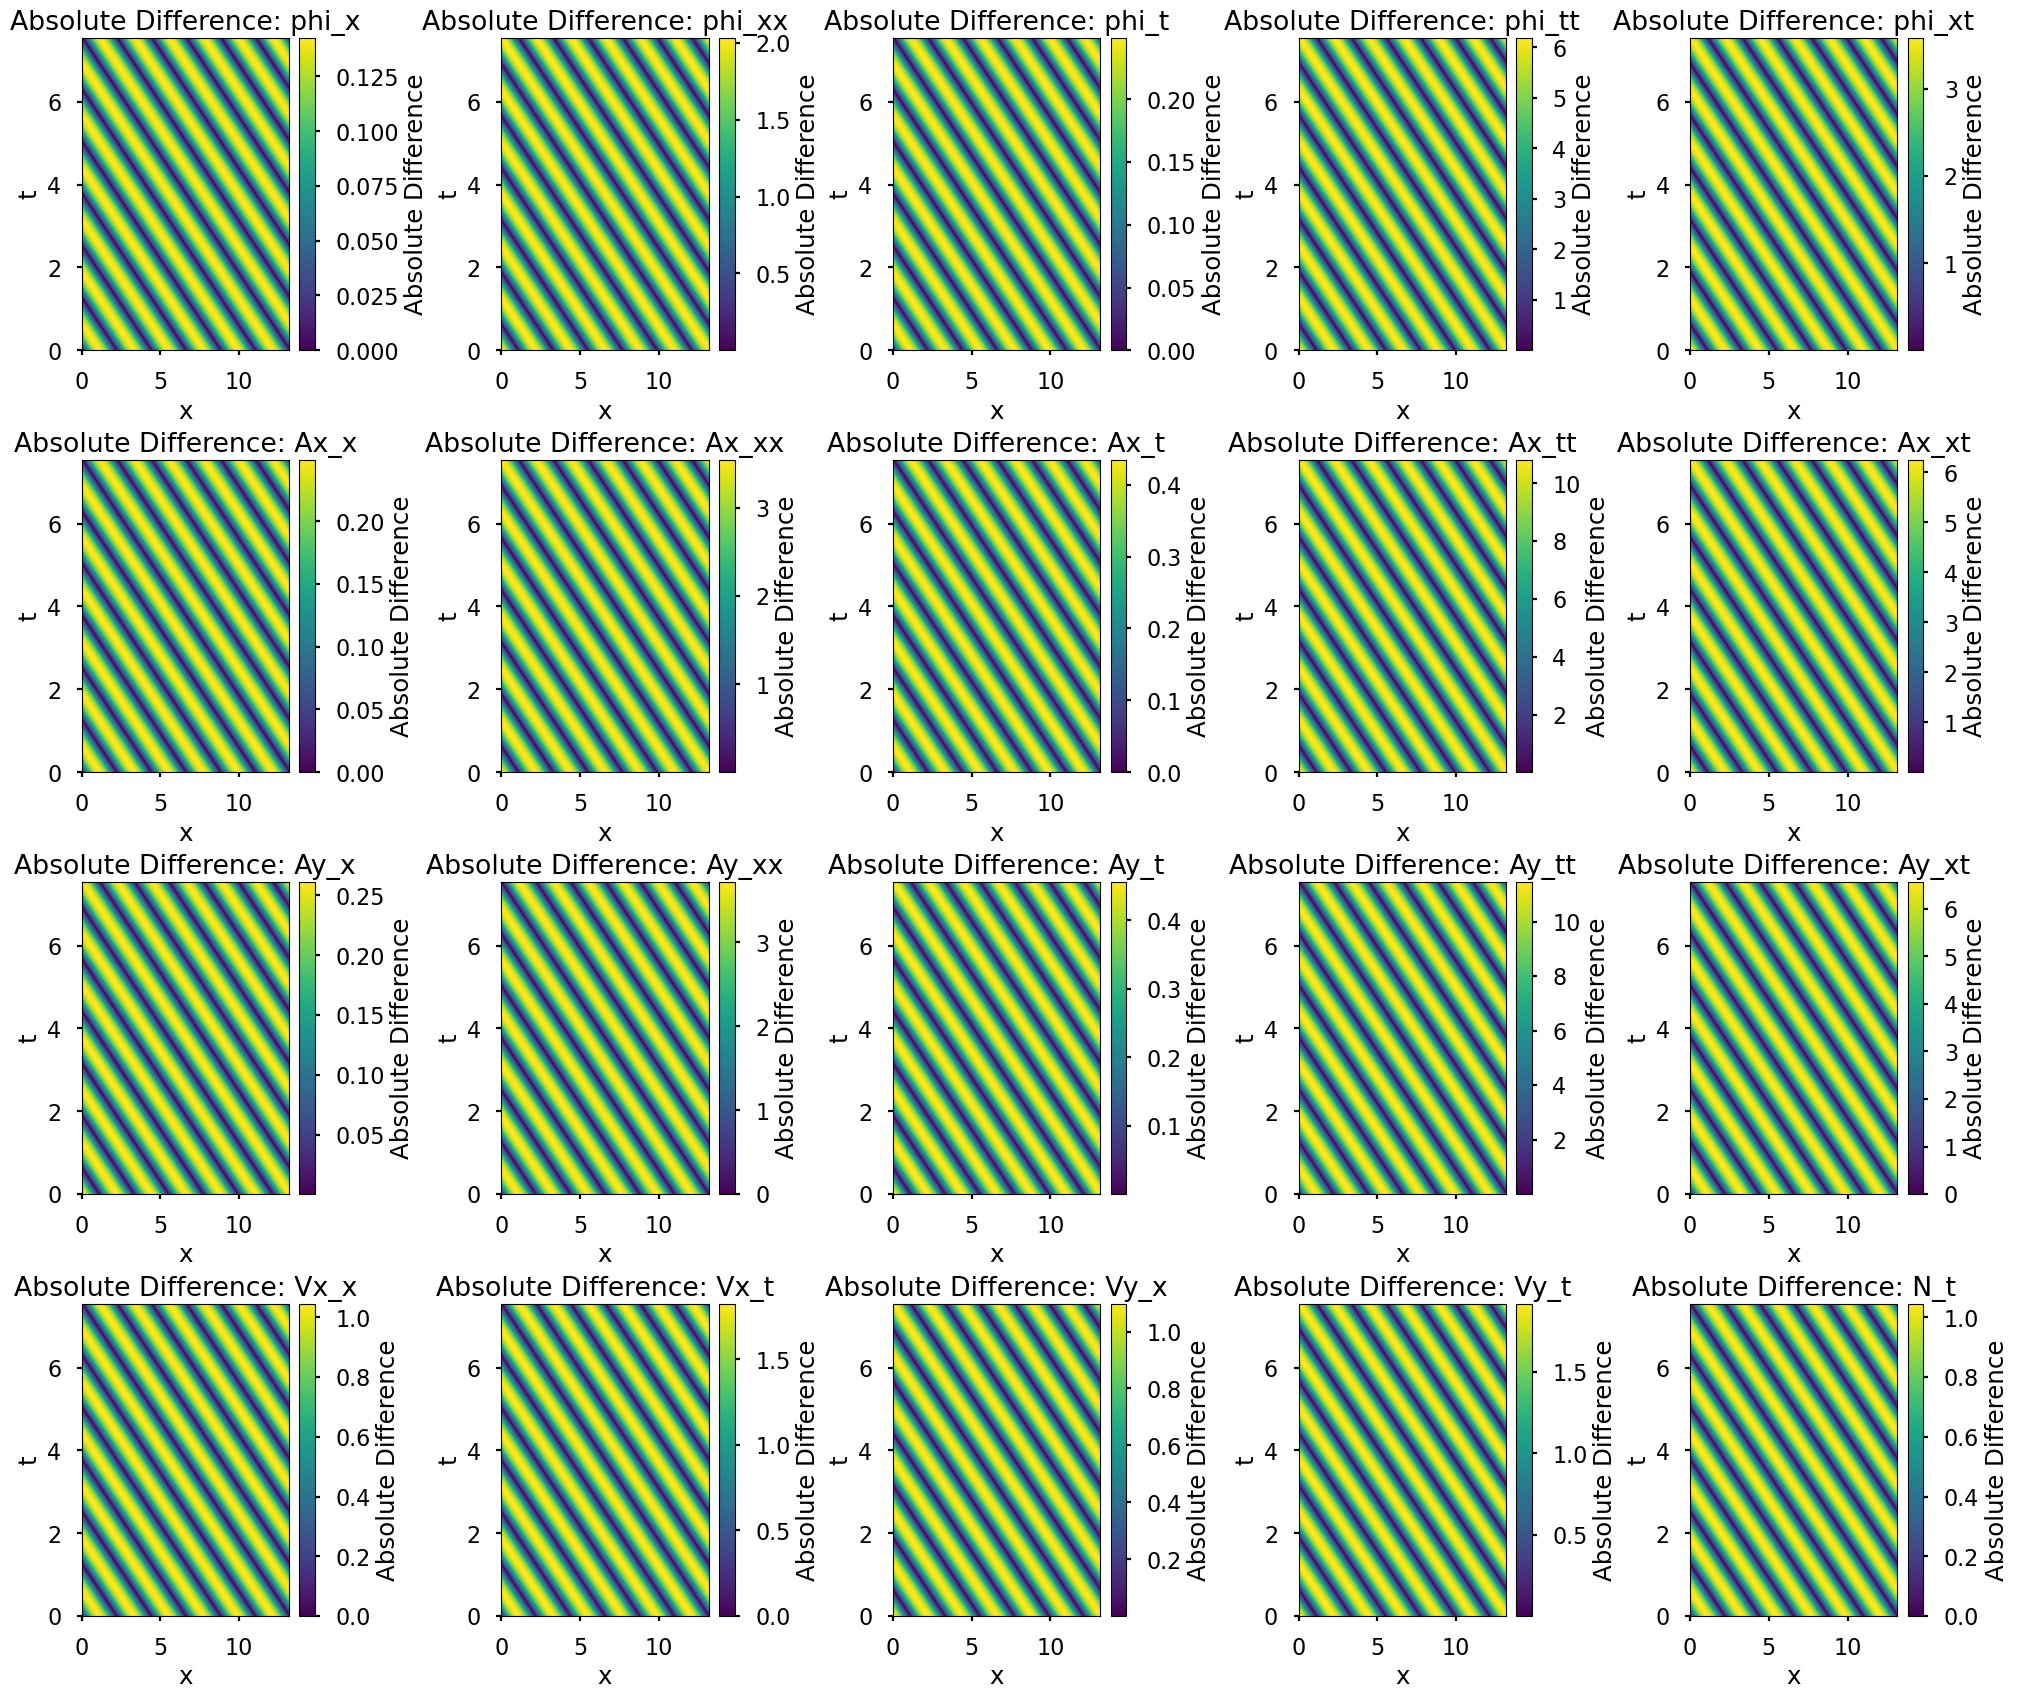

In [6]:
# phi = quantities_GT[0]
# Bdot= quantities_GT[1]
# Ax = quantities_GT[2]
# Ay = quantities_GT[3]
# Vx = quantities_GT[4]
# Vy = quantities_GT[5]
# N = quantities_GT[6]


# #Numerical Derivatives
# phi_x = derivative_x(phi, dx)
# phi_xx = derivative_x(phi_x, dx)
# phi_t = derivative_t(phi, dt)
# phi_tt = derivative_t(phi_t, dt)
# phi_xt = derivative_t(phi_x, dt)

# Ax_x = derivative_x(Ax, dx)
# Ax_xx = derivative_x(Ax_x, dx)
# Ax_t = derivative_t(Ax, dt)
# Ax_tt = derivative_t(Ax_t, dt)
# Ax_xt = derivative_t(Ax_x, dx)
# Ay_x = derivative_x(Ay, dx)
# Ay_xx = derivative_x(Ay_x, dx)
# Ay_t = derivative_t(Ay, dt)
# Ay_tt = derivative_t(Ay_t, dt)
# Ay_xt = derivative_t(Ay_x, dt)

# Vx_x = derivative_x(Vx, dx)
# Vx_t = derivative_t(Vx, dt)
# Vy_x = derivative_x(Vy, dx)
# Vy_t = derivative_t(Vy, dt)

# N_t = derivative_t(N, dt)

num_sols = [phi_x, phi_xx, phi_t, phi_tt, phi_xt,
            Ax_x, Ax_xx, Ax_t, Ax_tt, Ax_xt,
            Ay_x, Ay_xx, Ay_t, Ay_tt, Ay_xt,
            Vx_x, Vx_t, Vy_x, Vy_t, N_t]

#analytical derivatives
phi_x_analytical = 1j*k*phi
phi_xx_analytical = -(k**2) * phi
phi_t_analytical = -1j*omega*phi
phi_tt_analytical = -(omega**2) * phi
phi_xt_analytical = omega*k*phi

Ax_x_analytical = 1j*k*Ax
Ax_xx_analytical = -(k**2)*Ax
Ax_t_analytical = -1j*omega*Ax
Ax_tt_analytical = -(omega**2)*Ax
Ax_xt_analytical = omega*k*Ax
Ay_x_analytical = 1j*k*Ay
Ay_xx_analytical = -(k**2)*Ay
Ay_t_analytical = -1j*omega*Ay
Ay_tt_analytical = -(omega**2)*Ay
Ay_xt_analytical = omega*k*Ay

Vx_x_analytical = 1j*k*Vx
Vx_t_analytical = -1j*omega*Vx
Vy_x_analytical = 1j*k*Vy
Vy_t_analytical = -1j*omega*Vy

N_t_analytical = -1j*omega*N

analytical_sols = np.real(np.array([phi_x_analytical, phi_xx_analytical, phi_t_analytical, phi_tt_analytical, phi_xt_analytical,
            Ax_x_analytical, Ax_xx_analytical, Ax_t_analytical, Ax_tt_analytical, Ax_xt_analytical,
            Ay_x_analytical, Ay_xx_analytical, Ay_t_analytical, Ay_tt_analytical, Ay_xt_analytical,
            Vx_x_analytical, Vx_t_analytical, Vy_x_analytical, Vy_t_analytical, N_t_analytical]))

titles_sols = ['phi_x', 'phi_xx', 'phi_t', 'phi_tt', 'phi_xt',
               'Ax_x', 'Ax_xx', 'Ax_t', 'Ax_tt', 'Ax_xt',
               'Ay_x', 'Ay_xx', 'Ay_t', 'Ay_tt', 'Ay_xt',
               'Vx_x', 'Vx_t', 'Vy_x', 'Vy_t', 'N_t']
def compare_derives(analytical_sols, num_sols, titles, extent):
    # This creates a 5x4 grid, so axs is a 2D NumPy array of Axes objects.
    # I've changed it to 2x2 to match the mock data.
     # Create a 5x5 grid to accommodate all 21 derivatives
    fig, axs = plt.subplots(5, 5, figsize=(20, 20), constrained_layout=True)

    # Flatten the axes array to easily iterate
    axs = axs.flatten()

    for i, (analytical, numerical, title) in enumerate(zip(analytical_sols, num_sols, titles)):
        if i < len(axs):
            ax = axs[i]
            # Calculate the absolute difference between the solutions
            difference = np.abs(analytical - numerical)
            epsilon=1e-12
            rel_error = difference/(np.abs(analytical)+epsilon)
            percent_accuracy = (1-rel_error)*100
            mean_accuracy = np.mean(percent_accuracy)

            # Plot the difference using imshow
            im = ax.imshow(np.abs(difference), extent=extent, aspect='auto')
            fig.colorbar(im, ax=ax, label='Absolute Difference')

            ax.set_title(f'Absolute Difference: {title}')
            ax.set_xlabel('x')
            ax.set_ylabel('t')

    # Hide any unused subplots
    for j in range(len(analytical_sols), len(axs)):
        fig.delaxes(axs[j])


    plt.show()
compare_derives(analytical_sols, num_sols, titles=titles_sols, extent=extent_GT)

In [1]:
from PINN_XWave_DDP import main
if __name__ == '__main__':
    main()

/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:348: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:352: SyntaxWarning: invalid escape sequence '\p'
  if f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$' in title:
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:355: SyntaxWarning: invalid escape sequence '\d'
  if f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$' in title:
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:374: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


-----Training Model----------
-----Training Model----------
Initializing NN with glorot initialization...



MLP tmin: 0.0000, MLP tmax: 7.5398, MLP xmin: 0.0000, MLP xmax: 13.1651

Number of hidden layers: 4
Hidden layer size: 50 nodes / layer
Input size: 100
Output size: 7

Activation function used: Sin()
NN parameter initialization mode used: xavier
Use Fourier feature input encoding? True
Sigma of Fourier feature input encoding = 1.0


Network architecture: Sequential(
  (input_layer): Linear(in_features=100, out_features=50, bias=True)
  (input_activation): Sin()
  (hidden_layer_0): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_0): Sin()
  (hidden_layer_1): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_1): Sin()
  (hidden_layer_2): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_2): Sin()
  (hidden_layer_3): Linear(in_features=50, out_features=50, bias=True)
  (hidden_activation_3): Sin()
  (output_layer):

/home/aleotz/.conda/envs/pinn_recon/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/home/aleotz/.conda/envs/pinn_recon/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0/2000, Total Loss: 1.5166e+02, SM Loss: 2.4349e+00, Physics Loss: 1.4923e+02
Epoch 50/2000, Total Loss: 2.4982e+00, SM Loss: 1.9833e+00, Physics Loss: 5.1490e-01
Epoch 100/2000, Total Loss: 2.0982e+00, SM Loss: 1.9729e+00, Physics Loss: 1.2534e-01
Epoch 150/2000, Total Loss: 2.0137e+00, SM Loss: 1.9618e+00, Physics Loss: 5.1820e-02
Epoch 200/2000, Total Loss: 1.9720e+00, SM Loss: 1.9301e+00, Physics Loss: 4.1904e-02
Epoch 250/2000, Total Loss: 1.9217e+00, SM Loss: 1.8515e+00, Physics Loss: 7.0206e-02
Epoch 300/2000, Total Loss: 1.8576e+00, SM Loss: 1.7460e+00, Physics Loss: 1.1157e-01
Epoch 350/2000, Total Loss: 1.7669e+00, SM Loss: 1.5895e+00, Physics Loss: 1.7742e-01
Epoch 400/2000, Total Loss: 1.4947e+00, SM Loss: 1.1506e+00, Physics Loss: 3.4402e-01
Epoch 450/2000, Total Loss: 1.4547e+00, SM Loss: 1.0879e+00, Physics Loss: 3.6679e-01
Epoch 500/2000, Total Loss: 1.4335e+00, SM Loss: 1.0597e+00, Physics Loss: 3.7388e-01
Epoch 550/2000, Total Loss: 1.4146e+00, SM Loss: 1.0404e+

In [4]:
import pickle
from PINN_XWave_DDP import plot_loss_histories
import torch
with open('ddp_xwave_hist.pkl', 'rb') as f:
    history = pickle.load(f)
with open('ddp_xwave_pinn_model.pt') as f:
    model = torch.load(f)
plot_loss_histories(history)

/tmp/ipykernel_1076782/914536436.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f)


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 64: invalid start byte

In [ ]:
plot_reconstructed_quantities(device=model.device, model=model, extent=extent_GT)

NameError: name 'plot_reconstructed_quantities' is not defined